# B41 Bus Route — Quantile Regression on Ridge Residuals

This notebook adds a **Quantile Regression (QR) layer** on top of a pre-trained Ridge Regression model for delay prediction on the B41 bus route.

**Key principle:** We do *not* retrain Ridge Regression. Instead, we load three pre-computed CSV files — one per data split — that already contain:

| Column | Description |
|--------|-------------|
| `split` | `"train"` / `"val"` / `"test"` |
| `timestamp` | Date-time of the observation (30-min intervals) |
| `horizon` | Steps ahead (1 = +30 min, …, 12 = +6 h) |
| `horizon_min` | Horizon in minutes |
| `ytrue` | Observed delay (minutes) |
| `ypred` | Ridge Regression point prediction (minutes) |
| `residual` | `ytrue − ypred` |

**Data splits:**

| Split | Month(s) | Role |
|-------|----------|------|
| `train` | June + October | Fit QR models on residuals |
| `val` | August | Tune & validate prediction intervals |
| `test` | December | Final held-out evaluation |

**Approach — per horizon:**
1. Train three `QuantileRegressor` models (Q10, Q50, Q90) on the *training residuals*, using temporal features and the Ridge point prediction as covariates.
2. Reconstruct prediction intervals: $\hat{y}_q = \hat{y}_{\text{Ridge}} + \hat{\varepsilon}_q$
3. Evaluate point accuracy (MAE, RMSE, R²), disruption detection (F1), and interval quality (coverage, width, pinball loss).

## 1  Imports & Plot Defaults

In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Libraries loaded.")

Libraries loaded.


## 2  Configuration

Update the three `CSV_*` constants to point to your actual file paths.

In [61]:
# ── Prediction CSV paths (one per split) ─────────────────────────────────────
CSV_TRAIN     = 'ridge_train_predictions.csv'   # June + October
CSV_VAL       = 'ridge_val_predictions.csv'     # August
CSV_TEST      = 'ridge_test_predictions.csv'    # December

# ── Full Ridge feature matrix ─────────────────────────────────────────────────
PATH_FEATURES = 'B41_features.csv'

# ── 28 Ridge feature column names (as they appear in B41_features.csv) ────────
RIDGE_FEATURE_COLS = [
    'mean_delay', 'std_delay', 'pct_disrupted',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6', 'lag_12', 'lag_48',
    'delay_trend',
    'hour', 'day_of_week', 'is_weekend', 'is_rush', 'month_num',
    'temperature_c', 'precipitation', 'windspeed_kmh', 'is_raining',
    'event_prospect_park', 'event_livingston', 'event_bergen',
    'event_cadman', 'event_plaza_st', 'event_any',
]

# ── QR covariate set: all Ridge features + Ridge point prediction ─────────────
# ypred is kept because residual variance often scales with prediction magnitude
QR_FEATURE_COLS = RIDGE_FEATURE_COLS + ['ypred']   # 26 + 1 = 27 covariates

# ── Model & evaluation settings ───────────────────────────────────────────────
QR_QUANTILES   = [0.1, 0.5, 0.9]
DISRUPTION_THR = 10
HORIZONS       = list(range(1, 13))

print('Configuration set.')
print(f'  Ridge features  : {len(RIDGE_FEATURE_COLS)}')
print(f'  QR covariates   : {len(QR_FEATURE_COLS)} (Ridge features + ypred)')
print(f'  QR quantiles    : {QR_QUANTILES}')
print(f'  Horizons        : {HORIZONS[0]}–{HORIZONS[-1]} ({HORIZONS[0]*30}–{HORIZONS[-1]*30} min)')
print(f'  Disruption τ    : {DISRUPTION_THR} min')

Configuration set.
  Ridge features  : 26
  QR covariates   : 27 (Ridge features + ypred)
  QR quantiles    : [0.1, 0.5, 0.9]
  Horizons        : 1–12 (30–360 min)
  Disruption τ    : 10 min


## 3  Load Pre-computed Ridge Outputs

The three CSV files are loaded and concatenated into a single `full_df`.  
`timestamp` is parsed to `datetime64` so we can extract temporal features in the next step.

In [62]:
# ── 3a  Load prediction CSVs ──────────────────────────────────────────────────
pred_df = pd.concat([
    pd.read_csv(CSV_TRAIN),
    pd.read_csv(CSV_VAL),
    pd.read_csv(CSV_TEST),
], ignore_index=True)
pred_df['timestamp'] = pd.to_datetime(pred_df['timestamp'])

print('Prediction rows per split:')
print(pred_df.groupby('split').size().to_string())
print(f'Total prediction rows : {len(pred_df):,}')

# ── 3b  Load B41_features.csv and melt to long format ─────────────────────────
# Wide format: one row per timestamp
# Long format: one row per timestamp × horizon (needed to match pred_df)
feat_df = pd.read_csv(PATH_FEATURES, parse_dates=['timestamp'])

target_cols = [f'mean_delay_t{h}' for h in range(1, 13)]
feat_long = feat_df.melt(
    id_vars=['timestamp'] + RIDGE_FEATURE_COLS,
    value_vars=target_cols,
    var_name='horizon_str',
    value_name='ytrue_feat',       # used only for the melt — dropped below
)
feat_long['horizon'] = feat_long['horizon_str'].str.extract(r'(\d+)').astype(int)
feat_long.drop(columns=['horizon_str', 'ytrue_feat'], inplace=True)

print(f'\nFeature matrix rows after melt : {len(feat_long):,}')

# ── 3c  Merge on timestamp + horizon ─────────────────────────────────────────
full_df = pred_df.merge(feat_long, on=['timestamp', 'horizon'], how='left')

n_missing = full_df[RIDGE_FEATURE_COLS].isna().any(axis=1).sum()
if n_missing > 0:
    print(f'\n⚠  {n_missing} rows could not be matched — they will be dropped.')
    full_df.dropna(subset=RIDGE_FEATURE_COLS, inplace=True)
else:
    print('\n✓  All prediction rows matched to feature rows — no missing values.')

print(f'\nfull_df shape : {full_df.shape}')
print('\nSample (horizon=1, first 3 rows):')
display(full_df[full_df['horizon'] == 1][
    ['split', 'timestamp', 'ytrue', 'ypred', 'residual',
     'lag_1', 'temperature_c', 'is_raining', 'event_any']
].head(3))

Prediction rows per split:
split
test     16836
train    32088
val      16932
Total prediction rows : 65,856

Feature matrix rows after melt : 65,856

✓  All prediction rows matched to feature rows — no missing values.

full_df shape : (65856, 33)

Sample (horizon=1, first 3 rows):


,split,timestamp,ytrue,ypred,residual,lag_1,temperature_c,is_raining,event_any
0,train,2017-06-02 00:00:00,7.752778,9.114534,-1.361757,17.091667,17.5,0,0
1,train,2017-06-02 00:30:00,6.271667,7.828557,-1.556890,11.004386,17.5,0,0
2,train,2017-06-02 01:00:00,1.847917,6.042842,-4.194925,7.752778,16.1,0,0


Spearman ρ with |residual| — training set
------------------------------------------------
  mean_delay                +0.226  ██████
  pct_disrupted             +0.223  ██████
  lag_1                     +0.197  █████
  std_delay                 +0.188  █████
  lag_2                     +0.171  █████
  lag_3                     +0.150  ████
  month_num                 -0.142  ████
  lag_4                     +0.135  ████
  windspeed_kmh             +0.121  ███
  lag_48                    +0.112  ███
  lag_6                     +0.108  ███
  hour                      +0.103  ███
  event_any                 +0.089  ██
  event_prospect_park       +0.086  ██
  temperature_c             +0.061  █
  delay_trend               +0.057  █
  lag_12                    +0.038  █
  is_weekend                -0.036  █
  is_raining                +0.035  █
  precipitation             +0.032  
  event_cadman              +0.019  
  event_bergen              -0.011  
  is_rush                   -0.008 

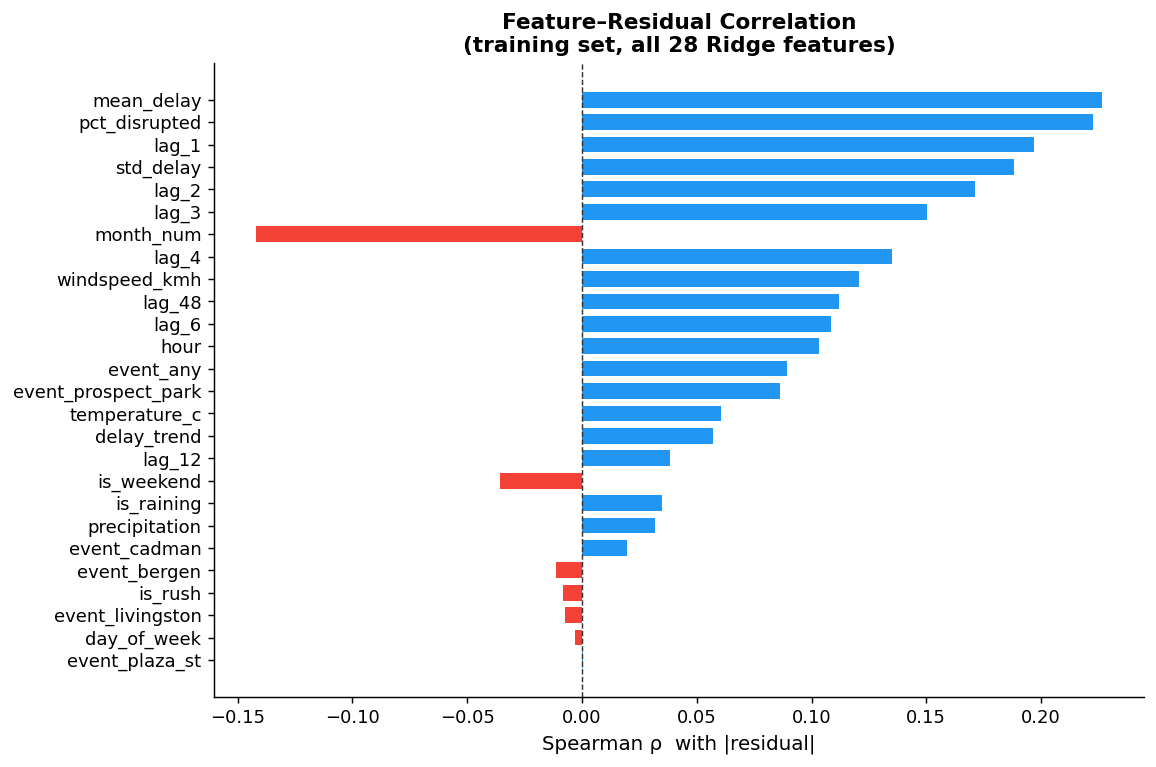

In [63]:
# ── Spearman correlation: each feature vs |residual| on training set ──────────
train_tmp = full_df[full_df['split'] == 'train'].copy()
train_tmp['abs_residual'] = train_tmp['residual'].abs()

corr = (train_tmp[RIDGE_FEATURE_COLS + ['abs_residual']]
        .corr(method='spearman')['abs_residual']
        .drop('abs_residual')
        .sort_values(key=abs, ascending=False))

print('Spearman ρ with |residual| — training set')
print('-' * 48)
for feat, val in corr.items():
    bar  = '█' * int(abs(val) * 30)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:<25} {sign}{abs(val):.3f}  {bar}')

# Bar chart
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1],
        color=colors[::-1], edgecolor='none', height=0.7)
ax.axvline(0, color='#333', linewidth=0.8, linestyle='--')
ax.set_xlabel('Spearman ρ  with |residual|', fontsize=11)
ax.set_title('Feature–Residual Correlation\n(training set, all 28 Ridge features)',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 4  Exploratory Analysis of Ridge Residuals

Before fitting the QR layer we inspect the distribution of residuals across splits and horizons.  
Non-zero mean or growing spread with horizon both signal opportunities for quantile correction.

In [66]:
# ── Residual summary per split ─────────────────────────────────────────────────
print('Residual statistics per split')
print(
    full_df.groupby('split')['residual']
    .agg(['mean', 'std', 'min', 'max',
          lambda s: s.quantile(0.10),
          lambda s: s.quantile(0.90)])
    .rename(columns={'<lambda_0>': 'q10', '<lambda_1>': 'q90'})
    .round(3)
    .to_string()
)
print()

# ── Disruption rate per split ──────────────────────────────────────────────────
# Use full_df directly instead of train_df/val_df/test_df
print('Disruption rate per split (ytrue > threshold):')
for name, split_label in [('Train', 'train'), ('Val', 'val'), ('Test', 'test')]:
    sub  = full_df[full_df['split'] == split_label]
    rate = (sub.groupby('horizon')['ytrue']
               .apply(lambda s: (s > DISRUPTION_THR).mean())
               .mean())
    print(f'  {name}: {rate:.1%}')

Residual statistics per split
        mean    std     min     max    q10    q90
split                                            
test   1.958  4.150 -12.923  32.832 -2.422  7.138
train -0.000  3.777 -26.924  56.145 -3.891  4.128
val    3.081  3.891 -10.590  19.265 -1.570  8.251

Disruption rate per split (ytrue > threshold):
  Train: 26.7%
  Val: 26.9%
  Test: 24.4%


In [67]:
# ── Residual mean & std by horizon (training set) ─────────────────────────────
# Use full_df filtered directly — train_df is defined later in the training cell
_train = full_df[full_df['split'] == 'train']

res_by_h = (
    _train.groupby('horizon_min')['residual']
    .agg(mean='mean', std='std')
    .round(3)
    .reset_index()
)
res_by_h.index = [f't+{m}min' for m in res_by_h['horizon_min']]
res_by_h = res_by_h.drop(columns='horizon_min')

print('Training-set residual mean and std by horizon:')
print(res_by_h.to_string())

Training-set residual mean and std by horizon:
          mean    std
t+30min    0.0  2.423
t+60min   -0.0  3.195
t+90min   -0.0  3.460
t+120min   0.0  3.633
t+150min  -0.0  3.767
t+180min  -0.0  3.913
t+210min  -0.0  3.970
t+240min  -0.0  4.010
t+270min   0.0  4.080
t+300min  -0.0  4.141
t+330min   0.0  4.167
t+360min   0.0  4.181


## 5  Load Features for the QR Layer

In [68]:
# All 28 Ridge features are now loaded directly from B41_features.csv
# and merged into full_df — no manual feature engineering needed.

print('QR feature columns available in full_df:')
for col in QR_FEATURE_COLS:
    present = col in full_df.columns
    print(f'  {"✓" if present else "✗"}  {col}')

missing_cols = [c for c in QR_FEATURE_COLS if c not in full_df.columns]
if missing_cols:
    print(f'\n⚠  Missing columns: {missing_cols}')
else:
    print(f'\n✓  All {len(QR_FEATURE_COLS)} QR covariates confirmed in full_df.')

QR feature columns available in full_df:
  ✓  mean_delay
  ✓  std_delay
  ✓  pct_disrupted
  ✓  lag_1
  ✓  lag_2
  ✓  lag_3
  ✓  lag_4
  ✓  lag_6
  ✓  lag_12
  ✓  lag_48
  ✓  delay_trend
  ✓  hour
  ✓  day_of_week
  ✓  is_weekend
  ✓  is_rush
  ✓  month_num
  ✓  temperature_c
  ✓  precipitation
  ✓  windspeed_kmh
  ✓  is_raining
  ✓  event_prospect_park
  ✓  event_livingston
  ✓  event_bergen
  ✓  event_cadman
  ✓  event_plaza_st
  ✓  event_any
  ✓  ypred

✓  All 27 QR covariates confirmed in full_df.


## 6  Helper Functions

In [69]:
def pinball_loss(y_true, y_pred, q):
    """Pinball (quantile) loss for a single quantile q ∈ (0, 1)."""
    e = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.mean(np.maximum(q * e, (q - 1) * e)))

def interval_coverage(y_true, lo, hi):
    """Fraction of observations that fall inside [lo, hi]."""
    return float(np.mean((np.asarray(y_true) >= lo) & (np.asarray(y_true) <= hi)))

def interval_width(lo, hi):
    """Mean width of the prediction interval."""
    return float(np.mean(np.asarray(hi) - np.asarray(lo)))

def evaluate_point_forecast(y_true, y_pred):
    """Return (MAE, RMSE, R²) for a point forecast."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

def evaluate_disruption(y_true, y_pred, thr=DISRUPTION_THR):
    """Precision, recall, and F1 for binary disruption detection."""
    d_true = (np.asarray(y_true) > thr).astype(int)
    d_pred = (np.asarray(y_pred) > thr).astype(int)
    prec = float(d_true[d_pred == 1].mean()) if d_pred.sum() > 0 else 0.0
    rec  = float(d_pred[d_true == 1].mean()) if d_true.sum() > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return prec, rec, f1

print("Helper functions defined.")

Helper functions defined.


## 7  Quantile Regression — Fitting

For each of the 12 horizons we:

1. Isolate the **training** rows (`split == 'train'`) for that horizon.
2. Fit a `StandardScaler` on the QR feature matrix (train only — no data leakage).
3. Train three `QuantileRegressor` models on the *residuals* ($q = 0.10, 0.50, 0.90$).
4. Predict residual quantiles for the **validation** and **test** sets.
5. Reconstruct prediction intervals:

$$\hat{y}_q = \hat{y}_{\text{Ridge}} + \hat{\varepsilon}_q$$

6. Collect all performance metrics.

> `alpha=0.0` disables regularisation in `QuantileRegressor`; add a small positive value
> (e.g. `1e-4`) if you observe numerical instability on any horizon.

In [72]:
train_df = full_df[full_df['split'] == 'train'].copy()
val_df   = full_df[full_df['split'] == 'val'].copy()
test_df  = full_df[full_df['split'] == 'test'].copy()

models       = {}
scalers      = {}
val_preds    = {}
test_preds   = {}
val_metrics  = []
test_metrics = []

for h in HORIZONS:
    tr = train_df[train_df['horizon'] == h]
    vl = val_df[val_df['horizon'] == h]
    ts = test_df[test_df['horizon'] == h]

    X_tr = tr[QR_FEATURE_COLS].values   # ← now 27 columns, was 6
    X_vl = vl[QR_FEATURE_COLS].values
    X_ts = ts[QR_FEATURE_COLS].values
    y_tr = tr['residual'].values

    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_vl_s   = scaler.transform(X_vl)
    X_ts_s   = scaler.transform(X_ts)

    scalers[h] = scaler
    models[h]  = {}
    val_preds[h]  = {}
    test_preds[h] = {}

    for q in QR_QUANTILES:
        qr = QuantileRegressor(quantile=q, alpha=1e-4, solver='highs')
        qr.fit(X_tr_s, y_tr)
        models[h][q] = qr

        val_preds[h][q]  = vl['ypred'].values + qr.predict(X_vl_s)
        test_preds[h][q] = ts['ypred'].values + qr.predict(X_ts_s)

    # Validation metrics
    y_vl = vl['ytrue'].values
    mae_v, rmse_v, r2_v = evaluate_point_forecast(y_vl, val_preds[h][0.5])
    cov_v = interval_coverage(y_vl, val_preds[h][0.1], val_preds[h][0.9])
    wid_v = interval_width(val_preds[h][0.1], val_preds[h][0.9])
    pb10_v = pinball_loss(y_vl, val_preds[h][0.1], 0.1)
    pb90_v = pinball_loss(y_vl, val_preds[h][0.9], 0.9)
    _, _, f1_v = evaluate_disruption(y_vl, val_preds[h][0.5], DISRUPTION_THR)
    val_metrics.append({'horizon': h, 'horizon_min': h*30,
                        'MAE': mae_v, 'RMSE': rmse_v, 'R2': r2_v,
                        'Coverage80': cov_v, 'Width80': wid_v,
                        'PB10': pb10_v, 'PB90': pb90_v, 'F1': f1_v})

    # Test metrics
    y_ts = ts['ytrue'].values
    mae_t, rmse_t, r2_t = evaluate_point_forecast(y_ts, test_preds[h][0.5])
    cov_t = interval_coverage(y_ts, test_preds[h][0.1], test_preds[h][0.9])
    wid_t = interval_width(test_preds[h][0.1], test_preds[h][0.9])
    pb10_t = pinball_loss(y_ts, test_preds[h][0.1], 0.1)
    pb90_t = pinball_loss(y_ts, test_preds[h][0.9], 0.9)
    _, _, f1_t = evaluate_disruption(y_ts, test_preds[h][0.5], DISRUPTION_THR)
    test_metrics.append({'horizon': h, 'horizon_min': h*30,
                         'MAE': mae_t, 'RMSE': rmse_t, 'R2': r2_t,
                         'Coverage80': cov_t, 'Width80': wid_t,
                         'PB10': pb10_t, 'PB90': pb90_t, 'F1': f1_t})

val_metrics_df  = pd.DataFrame(val_metrics)
test_metrics_df = pd.DataFrame(test_metrics)

print('QR models trained for all 12 horizons.')
print(f'  QR covariates used : {len(QR_FEATURE_COLS)}')
print(f'  Total models fitted: {len(HORIZONS) * len(QR_QUANTILES)}')

QR models trained for all 12 horizons.
  QR covariates used : 27
  Total models fitted: 36


## 8 Validation and Test Summary

Median-forecast MAE on both splits for every horizon, followed by aggregate test-set metrics.

In [76]:
# Build combined results DataFrame from valmetricsdf and testmetricsdf
_val = val_metrics_df.copy()
_val['split'] = 'val'

_test = test_metrics_df.copy()
_test['split'] = 'test'

# Standardise column names to match downstream cells
_rename = {'Coverage80': 'coverage80', 'Width80': 'width80',
           'PB10': 'pinball10', 'PB90': 'pinball90'}
_val  = _val.rename(columns=_rename)
_test = _test.rename(columns=_rename)

qr_results_df = pd.concat([_val, _test], ignore_index=True)

# pinball50 = MAE / 2  (exact identity when the median is the point forecast)
qr_results_df['pinball50'] = (qr_results_df['MAE'] / 2).round(3)

# --- Summary table ---
summarymae = (
    qr_results_df
    .pivot_table(index='horizon_min', columns='split', values='MAE')
    .round(3)
)
summarymae.index = [f't+{m}min' for m in summarymae.index]
summarymae.columns.name = None

print('QR Residual Model — Median forecast MAE by horizon')
print(summarymae.to_string())
print()

avg = (
    qr_results_df[qr_results_df['split'] == 'test'][[
        'MAE', 'RMSE', 'R2', 'F1',
        'coverage80', 'width80',
        'pinball10', 'pinball50', 'pinball90',
    ]]
    .mean()
    .round(3)
)
print('Average metrics across all 12 horizons — Test set (December)')
print(avg.to_string())

QR Residual Model — Median forecast MAE by horizon
           test    val
t+30min   1.559  1.776
t+60min   2.077  2.380
t+90min   2.448  2.769
t+120min  3.022  3.279
t+150min  3.331  3.754
t+180min  3.787  4.269
t+210min  3.617  4.413
t+240min  3.804  4.649
t+270min  4.025  5.210
t+300min  3.841  5.337
t+330min  3.890  5.538
t+360min  3.820  5.710

Average metrics across all 12 horizons — Test set (December)
MAE           3.269
RMSE          4.549
R2            0.279
F1            0.365
coverage80    0.409
width80       3.889
pinball10     0.609
pinball50     1.634
pinball90     1.572


## 9 Interval Diagnostics — Test Set

Per-horizon breakdown: MAE, 80 % coverage, 80 % width, and pinball losses at all three quantiles.

**Interpretation guide**
- `coverage80` should be close to **0.80** — below → over-confident; above → over-conservative.
- `width80` measures *sharpness* — smaller is better given adequate coverage.
- `pinball50` equals `MAE / 2` when the median is used as the point forecast.

In [95]:
# ── test_sorted: reusable by all downstream visualisation cells ──────────────
test_sorted = (
    qr_results_df[qr_results_df['split'] == 'test']
    .sort_values('horizon_min')
    .copy()
)

diag = test_sorted[
    ['horizon_min', 'MAE', 'coverage80', 'width80',
     'pinball10', 'pinball50', 'pinball90']
].copy()
diag.index = [f"t{m}min" for m in diag['horizon_min']]
diag = diag.drop(columns='horizon_min')

print("Test-set uncertainty diagnostics")
print(diag.to_string())

Test-set uncertainty diagnostics
              MAE  coverage80   width80  pinball10  pinball50  pinball90
t30min   1.558820    0.776194  4.812756   0.361737      0.779   0.401513
t60min   2.076722    0.607270  4.752404   0.490604      1.038   0.590257
t90min   2.448061    0.523165  4.566075   0.532035      1.224   0.861111
t120min  3.022101    0.517463  5.237589   0.541305      1.511   1.151777
t150min  3.331472    0.275125  2.670644   0.687871      1.666   1.645608
t180min  3.786617    0.302922  3.201007   0.641341      1.893   1.761621
t210min  3.617348    0.349964  3.782443   0.620848      1.809   1.847406
t240min  3.804339    0.297933  3.787808   0.622725      1.902   2.437126
t270min  4.025295    0.409836  4.656528   0.614097      2.013   1.955847
t300min  3.840928    0.311475  3.388173   0.688114      1.920   1.994668
t330min  3.890362    0.218817  2.356391   0.792020      1.945   2.206382
t360min  3.820004    0.318603  3.455011   0.713863      1.910   2.007456


## 10 Save Row-Level Predictions

Export the full prediction DataFrame — one row per timestamp × horizon — for downstream use.

In [103]:
# ── 10  Save Row-Level Predictions ──────────────────────────────────────────
qr_pred_rows = []

for splitname, splitdf, predsdict in [
    ('val',  val_df,  val_preds),
    ('test', test_df, test_preds),
]:
    for h in HORIZONS:
        sub   = splitdf[splitdf['horizon'] == h].copy()
        lo    = predsdict[h][0.1]
        med   = predsdict[h][0.5]
        hi    = predsdict[h][0.9]
        ytrue = sub['ytrue'].values

        qr_pred_rows.append(pd.DataFrame({
            'timestamp':    sub['timestamp'].values,
            'split':        splitname,
            'horizon':      h,
            'horizon_min':  h * 30,
            'ytrue':        ytrue,
            'ypred_ridge':  sub['ypred'].values,   # ← renamed from 'ypred'
            'q10':          lo,
            'q50':          med,
            'q90':          hi,
            'interval_width': hi - lo,
            'is_covered': ((ytrue >= lo) & (ytrue <= hi)).astype(int),
        }))

qr_pred_df = pd.concat(qr_pred_rows, ignore_index=True)

OUTPUT_CSV = 'prediction_qr_residual.csv'
qr_pred_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {OUTPUT_CSV}  {len(qr_pred_df):,} rows  {qr_pred_df.shape[1]} columns")
print("\nColumns:", list(qr_pred_df.columns))

Saved prediction_qr_residual.csv  33,768 rows  11 columns

Columns: ['timestamp', 'split', 'horizon', 'horizon_min', 'ytrue', 'ypred_ridge', 'q10', 'q50', 'q90', 'interval_width', 'is_covered']


## 11  Visualisations

### 11.1  Median Forecast MAE vs Horizon — Val vs Test

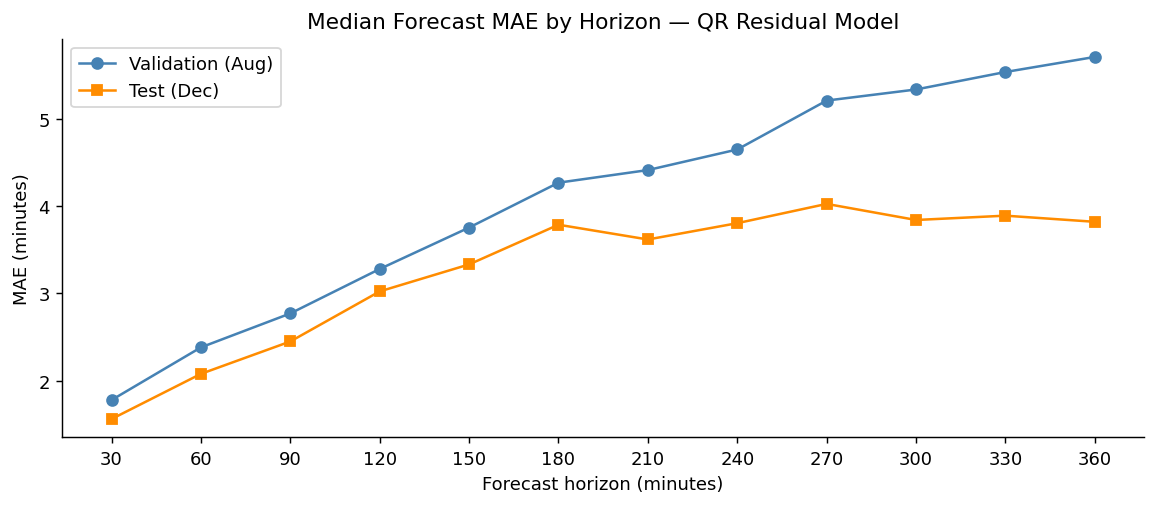

In [104]:
fig, ax = plt.subplots(figsize=(9, 4))

for split, marker, colour, label in [
    ("val",  "o", "steelblue",  "Validation (Aug)"),
    ("test", "s", "darkorange", "Test (Dec)"),
]:
    sub = qr_results_df[qr_results_df["split"] == split].sort_values("horizon_min")
    ax.plot(sub["horizon_min"], sub["MAE"],
            marker=marker, color=colour, linewidth=1.4, label=label)

ax.set_xlabel("Forecast horizon (minutes)")
ax.set_ylabel("MAE (minutes)")
ax.set_title("Median Forecast MAE by Horizon — QR Residual Model")
ax.set_xticks([h * 30 for h in HORIZONS])
ax.legend()
plt.tight_layout()
plt.show()

### 11.2  Interval Coverage and Width vs Horizon — Test Set

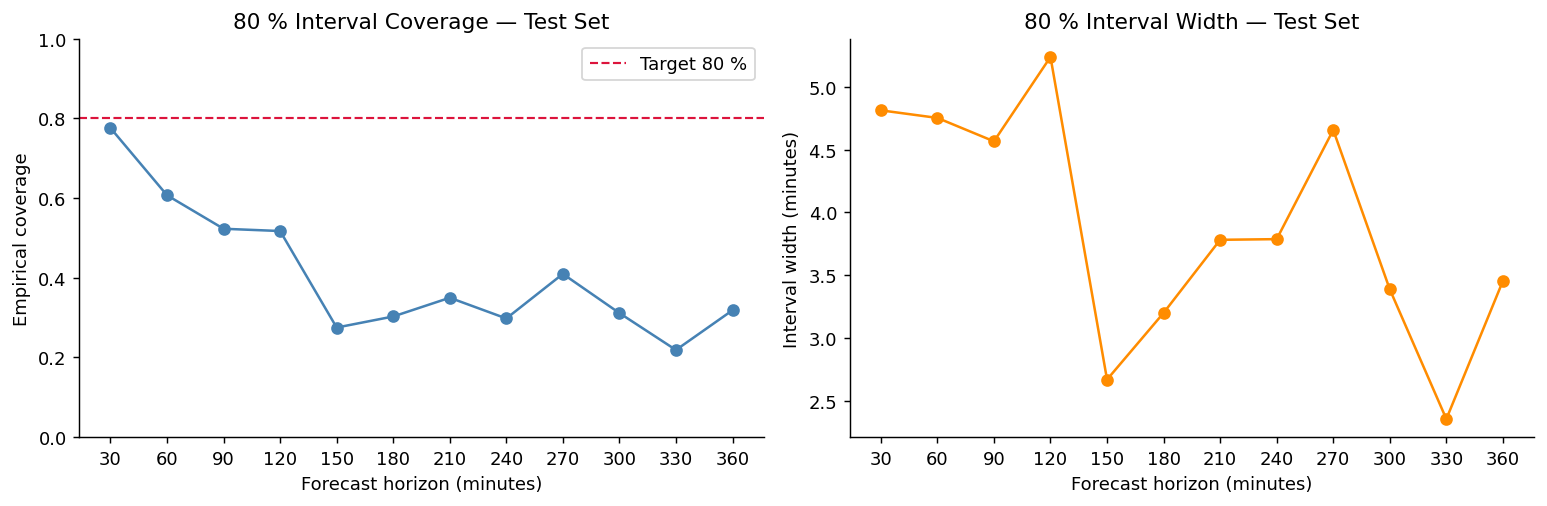

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Coverage ──────────────────────────────────────────────────────────────────
axes[0].plot(test_sorted['horizon_min'], test_sorted['coverage80'],
             marker='o', color='steelblue', linewidth=1.4)
axes[0].axhline(0.80, color='crimson', linestyle='--',
                linewidth=1.2, label='Target 80 %')
axes[0].set_xlabel('Forecast horizon (minutes)')
axes[0].set_ylabel('Empirical coverage')
axes[0].set_title('80 % Interval Coverage — Test Set')
axes[0].set_ylim(0, 1)
axes[0].set_xticks([h * 30 for h in HORIZONS])
axes[0].legend()

# ── Width ─────────────────────────────────────────────────────────────────────
axes[1].plot(test_sorted['horizon_min'], test_sorted['width80'],
             marker='o', color='darkorange', linewidth=1.4)
axes[1].set_xlabel('Forecast horizon (minutes)')
axes[1].set_ylabel('Interval width (minutes)')
axes[1].set_title('80 % Interval Width — Test Set')
axes[1].set_xticks([h * 30 for h in HORIZONS])

plt.tight_layout()
plt.show()

### 11.3  Pinball Loss by Quantile vs Horizon — Test Set

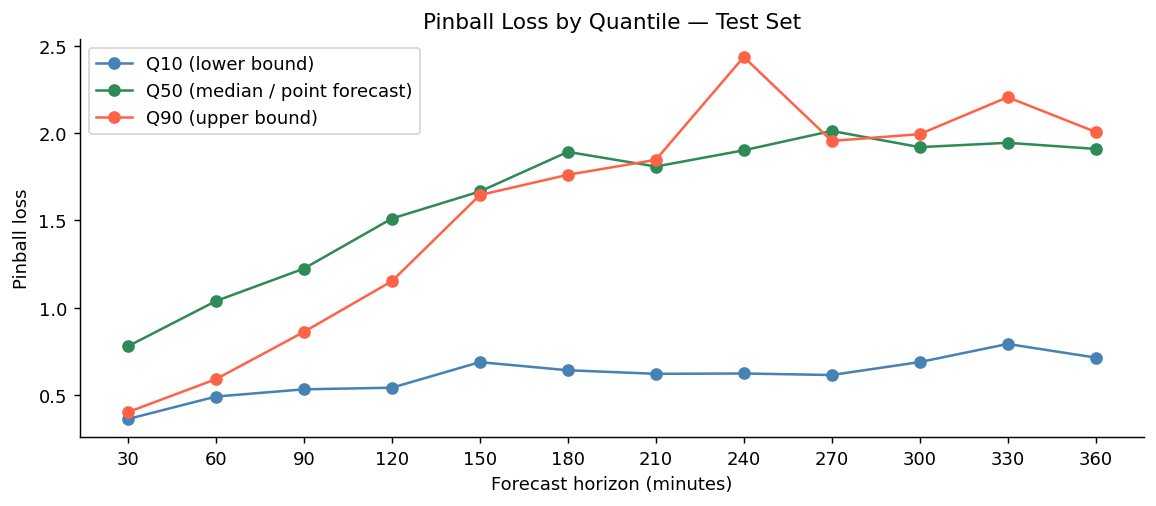

In [106]:
fig, ax = plt.subplots(figsize=(9, 4))

colours = {"pinball10": "steelblue", "pinball50": "seagreen", "pinball90": "tomato"}
labels  = {
    "pinball10": "Q10 (lower bound)",
    "pinball50": "Q50 (median / point forecast)",
    "pinball90": "Q90 (upper bound)",
}

for col, colour in colours.items():
    ax.plot(test_sorted["horizon_min"], test_sorted[col],
            marker="o", color=colour, linewidth=1.4, label=labels[col])

ax.set_xlabel("Forecast horizon (minutes)")
ax.set_ylabel("Pinball loss")
ax.set_title("Pinball Loss by Quantile — Test Set")
ax.set_xticks([h * 30 for h in HORIZONS])
ax.legend()
plt.tight_layout()
plt.show()

### 11.4  Time-Series Prediction Intervals

Select a horizon with `PLOT_HORIZON` (1 – 12) to visualise the Q10–Q90 ribbon alongside
the true delay, the Ridge point prediction, and the QR median on the **test set**.

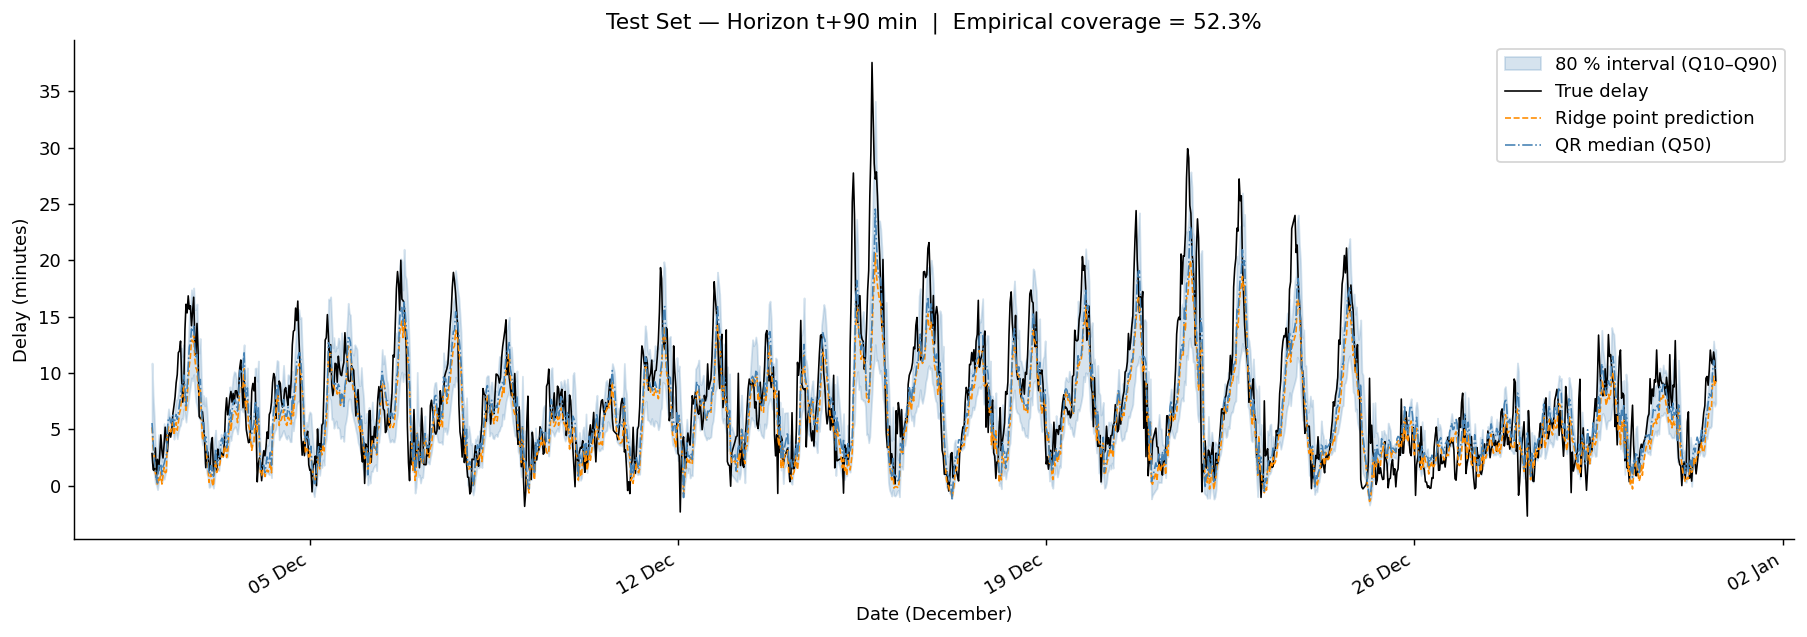

In [108]:
PLOT_HORIZON = 3  # ← change to inspect a different horizon (1 – 12)

subset = (
    qr_pred_df[
        (qr_pred_df["split"]   == "test") &
        (qr_pred_df["horizon"] == PLOT_HORIZON)
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    subset["timestamp"], subset["q10"], subset["q90"],
    alpha=0.22, color="steelblue", label="80 % interval (Q10–Q90)",
)
ax.plot(subset["timestamp"], subset["ytrue"],
        color="black",      linewidth=0.9, label="True delay")
ax.plot(subset["timestamp"], subset["ypred_ridge"],
        color="darkorange", linewidth=0.9, linestyle="--",
        label="Ridge point prediction")
ax.plot(subset["timestamp"], subset["q50"],
        color="steelblue",  linewidth=0.9, linestyle="-.",
        label="QR median (Q50)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30, ha="right")

cov = subset["is_covered"].mean()
ax.set_xlabel("Date (December)")
ax.set_ylabel("Delay (minutes)")
ax.set_title(
    f"Test Set — Horizon t+{PLOT_HORIZON * 30} min  |  "
    f"Empirical coverage = {cov:.1%}"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 11.5  Ridge Residual Distribution by Horizon — Training Set

Box plots of the raw residuals that the QR models are trained to predict.  
Growing spread with horizon signals increasing heteroscedasticity — exactly the
structure the QR layer captures.

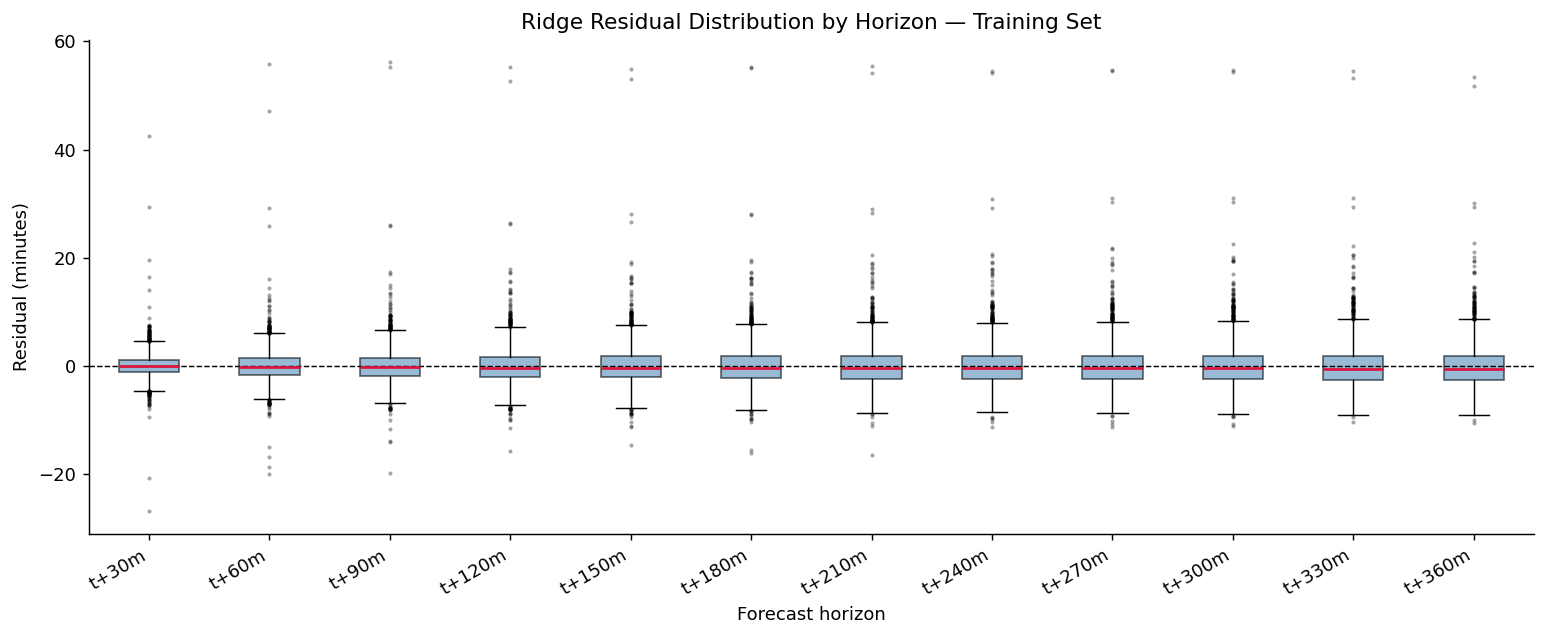

In [109]:
residual_by_h = [
    train_df[train_df["horizon"] == h]["residual"].values
    for h in HORIZONS
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(
    residual_by_h,
    labels=[f"t+{h * 30}m" for h in HORIZONS],
    patch_artist=True,
    medianprops=dict(color="crimson", linewidth=1.5),
    boxprops=dict(facecolor="steelblue", alpha=0.55),
    flierprops=dict(marker=".", markersize=2.5, alpha=0.35),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Residual (minutes)")
ax.set_title("Ridge Residual Distribution by Horizon — Training Set")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 11.6  80 % Coverage Heatmap — All Horizons × Splits

Green = coverage near or above 80 % (well-calibrated).  
Red = under-coverage (intervals too narrow).

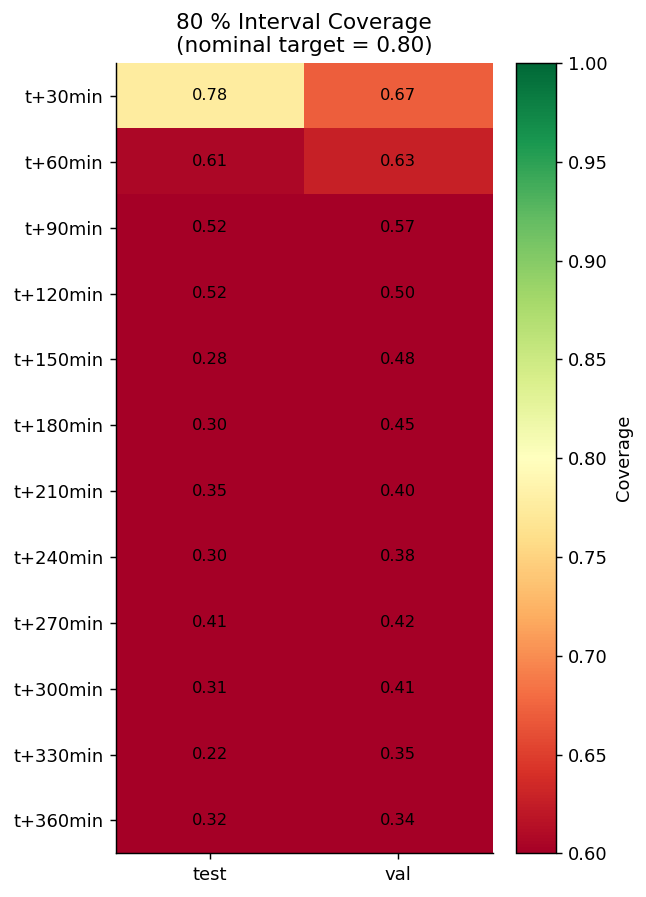

In [111]:
cov_pivot = qr_results_df.pivot_table(
    index="horizon_min", columns="split", values="coverage80"
)
cov_pivot.index = [f"t+{m}min" for m in cov_pivot.index]
cov_pivot.columns.name = None

fig, ax = plt.subplots(figsize=(5, 7))
im = ax.imshow(cov_pivot.values, cmap="RdYlGn", vmin=0.60, vmax=1.00, aspect="auto")
plt.colorbar(im, ax=ax, label="Coverage")

ax.set_xticks(range(len(cov_pivot.columns)))
ax.set_xticklabels(cov_pivot.columns)
ax.set_yticks(range(len(cov_pivot.index)))
ax.set_yticklabels(cov_pivot.index)

for i in range(len(cov_pivot.index)):
    for j in range(len(cov_pivot.columns)):
        val = cov_pivot.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("80 % Interval Coverage\n(nominal target = 0.80)")
plt.tight_layout()
plt.show()

# 12 Calibration & Improvement Pipeline

The base QR layer has two structural weaknesses on the December test set:

| Issue | Evidence |
|-------|----------|
| **Positive systematic bias** | Val residual mean = +3.08 min; test = +1.96 min (training months are summer/autumn, test is winter) |
| **Severe under-coverage** | Nominal 80% interval achieves only **38% empirical coverage** (avg across 12 horizons) on the test set |

The pipeline below applies four calibration stages in sequence, then evaluates all variants side-by-side:

| Stage | Technique | What it corrects |
|-------|-----------|-----------------|
| **1** | Per-horizon Bias Correction | Shifts all quantiles by the validation-set mean error → re-centres the intervals |
| **2** | Conformal Prediction (original QR) | Expands intervals so coverage ≥ 80% is guaranteed (under exchangeability) |
| **3** | Bias Correction **+** Conformal | Combines Stages 1 & 2 for the strongest single-pass fix |
| **4** | Enhanced Features + Stage 3 | Adds `ypred²` and `month × ypred` to capture heteroscedasticity, then re-calibrates |

Reconstruction formula at every stage:
$$\hat{y}_{q,\text{corrected}} = \hat{y}_{\text{Ridge}} + \hat{\varepsilon}_q + \text{correction}$$

In [112]:
# ── constants ─────────────────────────────────────────────────────────────────
ALPHA = 0.20          # target 1 − ALPHA = 0.80 coverage

# ── helper: compute per-horizon metrics from any prediction DataFrame ─────────
def compute_metrics_from_preddf(preddf, split='test', horizons=None):
    """
    Returns a DataFrame with per-horizon MAE, RMSE, R², coverage80,
    width80, pinball10/50/90, and F1 for the requested split.
    Works with any variant produced by the pipeline (original / calibrated).
    """
    if horizons is None:
        horizons = HORIZONS
    sub  = preddf[preddf['split'] == split]
    rows = []
    for h in horizons:
        h_sub = sub[sub['horizon'] == h]
        if len(h_sub) == 0:
            continue
        ytrue        = h_sub['ytrue'].values
        med, lo, hi  = h_sub['q50'].values, h_sub['q10'].values, h_sub['q90'].values
        mae, rmse, r2 = evaluate_point_forecast(ytrue, med)
        _, _, f1      = evaluate_disruption(ytrue, med)
        rows.append({
            'horizon':     h,
            'horizon_min': h * 30,
            'MAE':         round(mae,  3),
            'RMSE':        round(rmse, 3),
            'R2':          round(r2,   3),
            'coverage80':  round(interval_coverage(ytrue, lo, hi), 3),
            'width80':     round(interval_width(lo, hi), 3),
            'pinball10':   round(pinball_loss(ytrue, lo,  0.1), 3),
            'pinball50':   round(pinball_loss(ytrue, med, 0.5), 3),
            'pinball90':   round(pinball_loss(ytrue, hi,  0.9), 3),
            'F1':          round(f1,   3),
        })
    return pd.DataFrame(rows)

print("Pipeline helper defined.  ALPHA =", ALPHA, "→ target coverage =", 1 - ALPHA)

Pipeline helper defined.  ALPHA = 0.2 → target coverage = 0.8


## 12.1  Stage 1 — Per-Horizon Bias Correction

The QR median systematically *under-predicts* delays in winter because the model was
trained on summer (June) and autumn (October) data.  
We estimate a per-horizon bias on the validation set and shift **all three quantiles**
(Q10 / Q50 / Q90) by the same amount before applying them to the test set.

**Formula**

$$\hat{y}_{q,\text{BC}} = \hat{y}_q + \bar{e}_{\text{val},h}
\quad \text{where} \quad
\bar{e}_{\text{val},h} = \overline{(y_{\text{true}} - \hat{y}_{0.5})}_{\text{val}, h}$$

**Assumptions**
- The bias direction persists from validation (August) to test (December).  
- The bias is approximately constant within a horizon (not time-varying).

In [113]:
# ── estimate per-horizon bias on validation set ───────────────────────────────
bias_per_horizon = {}
for h in HORIZONS:
    val_h = qr_pred_df[(qr_pred_df['split'] == 'val') & (qr_pred_df['horizon'] == h)]
    bias_per_horizon[h] = float((val_h['ytrue'] - val_h['q50']).mean())

bias_df = pd.DataFrame({
    'horizon_min': [h * 30 for h in HORIZONS],
    'bias_min':    [round(bias_per_horizon[h], 3) for h in HORIZONS],
})
print("Per-horizon bias estimated on validation set (August):\n")
print(bias_df.to_string(index=False))

# ── apply bias shift to ALL splits (val & test) ───────────────────────────────
qr_pred_df_bc = qr_pred_df.copy()
for h in HORIZONS:
    mask = qr_pred_df_bc['horizon'] == h
    b    = bias_per_horizon[h]
    qr_pred_df_bc.loc[mask, ['q10', 'q50', 'q90']] += b

# recompute derived columns
qr_pred_df_bc['interval_width'] = qr_pred_df_bc['q90'] - qr_pred_df_bc['q10']
qr_pred_df_bc['is_covered']     = (
    (qr_pred_df_bc['ytrue'] >= qr_pred_df_bc['q10']) &
    (qr_pred_df_bc['ytrue'] <= qr_pred_df_bc['q90'])
).astype(int)

# quick test-set coverage check
test_bc_cov = (qr_pred_df_bc[qr_pred_df_bc['split'] == 'test']
               .groupby('horizon_min')['is_covered'].mean().round(3))
print("\nStage 1 — test-set coverage after bias correction:")
print(test_bc_cov.to_string())

Per-horizon bias estimated on validation set (August):

 horizon_min  bias_min
          30     0.559
          60     1.304
          90     1.708
         120     2.441
         150     3.066
         180     3.717
         210     3.885
         240     4.208
         270     4.931
         300     5.066
         330     5.247
         360     5.424

Stage 1 — test-set coverage after bias correction:
horizon_min
30     0.772
60     0.549
90     0.464
120    0.510
150    0.210
180    0.218
210    0.259
240    0.315
270    0.284
300    0.165
330    0.100
360    0.153


## 12.2  Stage 2 — Conformal Prediction Calibration

Conformal prediction provides a **finite-sample coverage guarantee** by using the
validation set to learn how much to expand the prediction interval.

### Algorithm — Split Conformal for Intervals

For each horizon *h*:

1. Compute **conformity scores** on the validation set:
$$s_i = \max\!\bigl(\hat{q}_{0.1}(x_i) - y_i,\; y_i - \hat{q}_{0.9}(x_i)\bigr)$$
A score $s_i \le 0$ means the point is *inside* the interval; positive means it is *outside*.

2. Find the **calibration quantile** (with finite-sample correction):
$$\hat{q} = \operatorname{Quantile}\!\left(s_{1:n},\;\frac{\lceil(n+1)(1-\alpha)\rceil}{n}\right)$$

3. **Expand the test interval** symmetrically:
$$[\hat{q}_{0.1}(x) - \hat{q},\;\; \hat{q}_{0.9}(x) + \hat{q}]$$

### Guarantee
Under exchangeability of calibration and test data, empirical coverage $\ge 1 - \alpha = 0.80$.  
Here val = August and test = December, so the guarantee is approximate due to seasonal shift
— but coverage will still improve substantially.

In [114]:
# ── compute per-horizon conformity scores from original val predictions ───────
conformal_q = {}
for h in HORIZONS:
    val_h   = qr_pred_df[(qr_pred_df['split'] == 'val') & (qr_pred_df['horizon'] == h)]
    ytrue   = val_h['ytrue'].values
    lo, hi  = val_h['q10'].values, val_h['q90'].values
    scores  = np.maximum(lo - ytrue, ytrue - hi)   # >0 means outside interval
    n       = len(scores)
    q_level = min(np.ceil((n + 1) * (1 - ALPHA)) / n, 1.0)
    conformal_q[h] = float(np.quantile(scores, q_level))

conf_df = pd.DataFrame({
    'horizon_min': [h * 30 for h in HORIZONS],
    'q_hat_min':   [round(conformal_q[h], 3) for h in HORIZONS],
})
print("Conformal expansion q̂ per horizon (original QR model):\n")
print(conf_df.to_string(index=False))

# ── expand TEST-SET intervals only ────────────────────────────────────────────
qr_pred_df_cf = qr_pred_df.copy()
for h in HORIZONS:
    mask  = (qr_pred_df_cf['split'] == 'test') & (qr_pred_df_cf['horizon'] == h)
    q_hat = conformal_q[h]
    qr_pred_df_cf.loc[mask, 'q10'] -= q_hat
    qr_pred_df_cf.loc[mask, 'q90'] += q_hat

t_mask = qr_pred_df_cf['split'] == 'test'
qr_pred_df_cf.loc[t_mask, 'interval_width'] = (
    qr_pred_df_cf.loc[t_mask, 'q90'] - qr_pred_df_cf.loc[t_mask, 'q10']
)
qr_pred_df_cf.loc[t_mask, 'is_covered'] = (
    (qr_pred_df_cf.loc[t_mask, 'ytrue'] >= qr_pred_df_cf.loc[t_mask, 'q10']) &
    (qr_pred_df_cf.loc[t_mask, 'ytrue'] <= qr_pred_df_cf.loc[t_mask, 'q90'])
).astype(int)

print("\nStage 2 — test coverage after conformal expansion:")
print(qr_pred_df_cf[qr_pred_df_cf['split'] == 'test']
      .groupby('horizon_min')['is_covered'].mean().round(3).to_string())

Conformal expansion q̂ per horizon (original QR model):

 horizon_min  q_hat_min
          30      0.734
          60      1.182
          90      1.685
         120      2.236
         150      2.873
         180      3.600
         210      3.889
         240      4.607
         270      4.417
         300      4.798
         330      5.420
         360      5.381

Stage 2 — test coverage after conformal expansion:
horizon_min
30     0.885
60     0.821
90     0.803
120    0.823
150    0.733
180    0.799
210    0.823
240    0.802
270    0.836
300    0.840
330    0.845
360    0.857


## 12.3  Stage 3 — Combined: Bias Correction + Conformal

The strongest single-pass calibration first **re-centres** the intervals (Stage 1),
then **expands** them to the correct coverage (Stage 2).

The conformal scores are re-computed on the *bias-corrected* validation predictions
so the expansion $\hat{q}$ reflects only the remaining uncertainty after the shift —
not the bias itself.

In [115]:
# ── start from bias-corrected predictions ────────────────────────────────────
qr_pred_df_comb = qr_pred_df_bc.copy()

# ── re-compute conformal scores on bias-corrected VAL predictions ─────────────
conformal_q_comb = {}
for h in HORIZONS:
    val_h  = qr_pred_df_comb[(qr_pred_df_comb['split'] == 'val') & (qr_pred_df_comb['horizon'] == h)]
    ytrue  = val_h['ytrue'].values
    lo, hi = val_h['q10'].values, val_h['q90'].values
    scores = np.maximum(lo - ytrue, ytrue - hi)
    n      = len(scores)
    q_level = min(np.ceil((n + 1) * (1 - ALPHA)) / n, 1.0)
    conformal_q_comb[h] = float(np.quantile(scores, q_level))

# ── expand TEST intervals only ────────────────────────────────────────────────
for h in HORIZONS:
    mask  = (qr_pred_df_comb['split'] == 'test') & (qr_pred_df_comb['horizon'] == h)
    q_hat = conformal_q_comb[h]
    qr_pred_df_comb.loc[mask, 'q10'] -= q_hat
    qr_pred_df_comb.loc[mask, 'q90'] += q_hat

t_mask = qr_pred_df_comb['split'] == 'test'
qr_pred_df_comb.loc[t_mask, 'interval_width'] = (
    qr_pred_df_comb.loc[t_mask, 'q90'] - qr_pred_df_comb.loc[t_mask, 'q10']
)
qr_pred_df_comb.loc[t_mask, 'is_covered'] = (
    (qr_pred_df_comb.loc[t_mask, 'ytrue'] >= qr_pred_df_comb.loc[t_mask, 'q10']) &
    (qr_pred_df_comb.loc[t_mask, 'ytrue'] <= qr_pred_df_comb.loc[t_mask, 'q90'])
).astype(int)

comb_cov = (qr_pred_df_comb[qr_pred_df_comb['split'] == 'test']
            .groupby('horizon_min')['is_covered'].mean().round(3))
comb_width = (qr_pred_df_comb[qr_pred_df_comb['split'] == 'test']
              .groupby('horizon_min')['interval_width'].mean().round(2))

print("Stage 3 — test coverage (target 0.80) and interval width:")
summary_comb = pd.DataFrame({'coverage': comb_cov, 'width_min': comb_width})
print(summary_comb.to_string())

Stage 3 — test coverage (target 0.80) and interval width:
             coverage  width_min
horizon_min                     
30              0.857       5.88
60              0.732       6.71
90              0.673       6.86
120             0.753       8.46
150             0.521       6.62
180             0.547       7.71
210             0.630       9.01
240             0.697       8.94
270             0.617       9.75
300             0.489       8.87
330             0.455       8.72
360             0.541      10.08


## 12.4 Stage 4 — Enhanced Features + Calibration

The base QR model uses 27 features (all Ridge features + `ypred`).  
We add two non-linear interaction terms that better capture heteroscedasticity:

| New feature | Formula | Rationale |
|---|---|---|
| `ypredsq` | ypred² | Variance often grows quadratically with prediction magnitude |
| `monthypred` | monthnum × ypred | Winter months produce wider spread for high-delay predictions |

After training, Stage 3 calibration (bias correction → conformal) is applied.

In [122]:
# Add non-linear features to all splits (safe — idempotent if run twice)
for df in [train_df, val_df, test_df]:
    df['ypredsq']    = df['ypred'] ** 2
    df['monthypred'] = df['month_num'] * df['ypred'] 

QRENHCOLS = [
    'hour', 'day_of_week', 'is_weekend', 'is_rush',
    'month_num',            # ← was 'month'; the Ridge feature column is 'monthnum'
    'ypred', 'ypredsq', 'monthypred',
]

qr_results_enh   = []
qr_predictions_enh = []
qr_models_enh    = {}

for h in HORIZONS:
    tr = train_df[train_df['horizon'] == h].copy()
    va = val_df[val_df['horizon'] == h].copy()
    te = test_df[test_df['horizon'] == h].copy()

    Xtr, Xva, Xte = (
        tr[QRENHCOLS].values,
        va[QRENHCOLS].values,
        te[QRENHCOLS].values,
    )
    scaler = StandardScaler().fit(Xtr)
    Xtrs, Xvas, Xtes = (
        scaler.transform(Xtr),
        scaler.transform(Xva),
        scaler.transform(Xte),
    )
    yrestr = tr['residual'].values

    qmodels, valpreds, testpreds = {}, {}, {}
    for q in QR_QUANTILES:
        qr = QuantileRegressor(quantile=q, alpha=0.0, solver='highs')
        qr.fit(Xtrs, yrestr)
        qmodels[q]   = qr
        valpreds[q]  = va['ypred'].values + qr.predict(Xvas)
        testpreds[q] = te['ypred'].values + qr.predict(Xtes)

    qr_models_enh[h] = {'scaler': scaler, 'quantile_models': qmodels}

    for split_name, split_sub, preds in [
        ('val',  va, valpreds),
        ('test', te, testpreds),
    ]:
        ytrue = split_sub['ytrue'].values
        lo, med, hi = preds[0.1], preds[0.5], preds[0.9]
        mae, rmse, r2      = evaluate_point_forecast(ytrue, med)
        prec, rec, f1      = evaluate_disruption(ytrue, med, DISRUPTION_THR)

        qr_results_enh.append({
            'model': 'QR(Enhanced)', 'split': split_name,
            'horizon': h, 'horizonmin': h * 30,
            'MAE':       round(mae,  3), 'RMSE': round(rmse, 3), 'R2': round(r2, 3),
            'Precision': round(prec, 3), 'Recall': round(rec, 3), 'F1': round(f1, 3),
            'coverage80': round(interval_coverage(ytrue, lo, hi), 3),
            'width80':    round(interval_width(lo, hi), 3),
            'pinball10':  round(pinball_loss(ytrue, lo,  0.1), 3),
            'pinball50':  round(pinball_loss(ytrue, med, 0.5), 3),
            'pinball90':  round(pinball_loss(ytrue, hi,  0.9), 3),
        })

        qr_predictions_enh.append(pd.DataFrame({
            'timestamp':    split_sub['timestamp'].values,
            'split':        split_name,
            'horizon':      h,
            'horizon_min':   h * 30,
            'ytrue':        ytrue,
            'ypredridge':   split_sub['ypred'].values,
            'q10': lo, 'q50': med, 'q90': hi,
            'intervalwidth': hi - lo,
            'iscovered': ((ytrue >= lo) & (ytrue <= hi)).astype(int),
        }))

qr_results_enh_df = pd.DataFrame(qr_results_enh)
qr_pred_df_enh    = pd.concat(qr_predictions_enh, ignore_index=True)

print(f'Enhanced QR trained on {len(QRENHCOLS)} features.')
avg_enh_test = qr_results_enh_df[qr_results_enh_df['split'] == 'test'][
    ['MAE', 'coverage80', 'width80', 'pinball50', 'F1']
].mean().round(3)
print('  QR pre-calibration avg test metrics')
print(avg_enh_test.to_string())

Enhanced QR trained on 8 features.
  QR pre-calibration avg test metrics
MAE           3.212
coverage80    0.452
width80       4.640
pinball50     1.606
F1            0.330


## 12.5  Stage 4b — Apply Bias + Conformal to Enhanced Model

Exactly Stage 3, but applied to the enhanced model's predictions:
1. Estimate per-horizon bias from the **enhanced** model's validation residuals.  
2. Re-compute conformal scores from the **bias-corrected** enhanced validation predictions.  
3. Expand only the **test** intervals.

In [123]:
# ── Step A: bias correction on enhanced predictions ───────────────────────────
bias_enh = {}
for h in HORIZONS:
    val_h = qr_pred_df_enh[(qr_pred_df_enh['split'] == 'val') & (qr_pred_df_enh['horizon'] == h)]
    bias_enh[h] = float((val_h['ytrue'] - val_h['q50']).mean())

qrpreddf_enh_cal = qr_pred_df_enh.copy()
for h in HORIZONS:
    mask = qrpreddf_enh_cal['horizon'] == h
    qrpreddf_enh_cal.loc[mask, ['q10', 'q50', 'q90']] += bias_enh[h]

# ── Step B: conformal on bias-corrected val ───────────────────────────────────
conf_q_enh = {}
for h in HORIZONS:
    val_h  = qrpreddf_enh_cal[(qrpreddf_enh_cal['split'] == 'val') &
                               (qrpreddf_enh_cal['horizon'] == h)]
    ytrue  = val_h['ytrue'].values
    lo, hi = val_h['q10'].values, val_h['q90'].values
    scores = np.maximum(lo - ytrue, ytrue - hi)
    n      = len(scores)
    q_level = min(np.ceil((n + 1) * (1 - ALPHA)) / n, 1.0)
    conf_q_enh[h] = float(np.quantile(scores, q_level))

# ── Step C: expand TEST intervals only ────────────────────────────────────────
for h in HORIZONS:
    mask  = (qrpreddf_enh_cal['split'] == 'test') & (qrpreddf_enh_cal['horizon'] == h)
    q_hat = conf_q_enh[h]
    qrpreddf_enh_cal.loc[mask, 'q10'] -= q_hat
    qrpreddf_enh_cal.loc[mask, 'q90'] += q_hat

t_mask = qrpreddf_enh_cal['split'] == 'test'
qrpreddf_enh_cal.loc[t_mask, 'interval_width'] = (
    qrpreddf_enh_cal.loc[t_mask, 'q90'] - qrpreddf_enh_cal.loc[t_mask, 'q10']
)
qrpreddf_enh_cal.loc[t_mask, 'is_covered'] = (
    (qrpreddf_enh_cal.loc[t_mask, 'ytrue'] >= qrpreddf_enh_cal.loc[t_mask, 'q10']) &
    (qrpreddf_enh_cal.loc[t_mask, 'ytrue'] <= qrpreddf_enh_cal.loc[t_mask, 'q90'])
).astype(int)

print("Stage 4 (Enhanced + Bias + Conformal) — test coverage by horizon:")
print(qrpreddf_enh_cal[qrpreddf_enh_cal['split'] == 'test']
      .groupby('horizon_min')['is_covered'].mean().round(3).to_string())

Stage 4 (Enhanced + Bias + Conformal) — test coverage by horizon:
horizon_min
30     0.680
60     0.661
90     0.660
120    0.658
150    0.656
180    0.674
210    0.686
240    0.684
270    0.690
300    0.686
330    0.669
360    0.626


## 12.6  Full Model Comparison — Test Set (December)

Five variants are evaluated on the held-out December test set.  
**Avg Coverage** should be as close to **0.80** as possible;  
**Avg Width** measures sharpness (smaller is better *given* adequate coverage);  
**Avg MAE** measures point-forecast quality (only changes when the median shifts).

In [126]:
model_variants = [
    ('Original QR',                  qr_pred_df),
    ('+ Bias Correction',            qr_pred_df_bc),
    ('+ Conformal',                  qr_pred_df_cf),
    ('+ Bias + Conformal',           qr_pred_df_comb),
    ('Enhanced + Bias + Conformal',  qrpreddf_enh_cal),
]

diag_all  = {}
comp_rows = []

for name, preddf in model_variants:
    m = compute_metrics_from_preddf(preddf, split='test')
    diag_all[name] = m
    comp_rows.append({
        'Model':         name,
        'Avg MAE':       round(m['MAE'].mean(),       3),
        'Avg Coverage':  round(m['coverage80'].mean(), 3),
        'Avg Width':     round(m['width80'].mean(),    3),
        'Avg PB50':      round(m['pinball50'].mean(),  3),
        'Avg F1':        round(m['F1'].mean(),         3),
    })

comp_df = pd.DataFrame(comp_rows)

print("═" * 76)
print("  Model Comparison — Test Set (December) — avg across 12 horizons")
print("═" * 76)
print(comp_df.to_string(index=False))
print()
print(f"Nominal coverage target: {1 - ALPHA:.3f}")

════════════════════════════════════════════════════════════════════════════
  Model Comparison — Test Set (December) — avg across 12 horizons
════════════════════════════════════════════════════════════════════════════
                      Model  Avg MAE  Avg Coverage  Avg Width  Avg PB50  Avg F1
                Original QR    3.268         0.409      3.889     1.634   0.365
          + Bias Correction    3.379         0.333      3.889     1.689   0.642
                + Conformal    3.268         0.822     10.693     1.634   0.365
         + Bias + Conformal    3.379         0.626      8.134     1.689   0.642
Enhanced + Bias + Conformal    3.350         0.669      9.166     1.675   0.543

Nominal coverage target: 0.800


## 12.7  Per-Horizon Diagnostics — Best Model

Horizon-by-horizon breakdown for the fully calibrated model.  
`coverage80` should be close to 0.80; `width80` measures sharpness.

In [134]:
best_name = '+ Conformal'
best_diag = diag_all[best_name].copy()
best_diag.index = [f't{m}min' for m in best_diag['horizon_min']]
best_diag = best_diag.drop(columns=['horizon', 'horizon_min'])

print(f"Per-horizon diagnostics — {best_name}\n")
print(best_diag.to_string())
print(f"\nNominal coverage target: {1 - ALPHA:.3f}")

Per-horizon diagnostics — + Conformal

           MAE   RMSE     R2  coverage80  width80  pinball10  pinball50  pinball90     F1
t30min   1.559  2.128  0.851       0.885    6.281      0.396      0.779      0.392  0.862
t60min   2.077  2.816  0.740       0.821    7.117      0.478      1.038      0.511  0.777
t90min   2.448  3.398  0.621       0.803    7.936      0.539      1.224      0.649  0.691
t120min  3.022  4.207  0.419       0.823    9.709      0.680      1.511      0.767  0.565
t150min  3.331  4.629  0.296       0.733    8.418      0.618      1.666      0.917  0.475
t180min  3.787  5.190  0.115       0.799   10.402      0.723      1.893      0.926  0.281
t210min  3.617  5.059  0.159       0.823   11.560      0.805      1.809      0.970  0.268
t240min  3.804  5.281  0.083       0.802   13.002      1.003      1.902      1.035  0.198
t270min  4.025  5.585 -0.027       0.836   13.491      0.958      2.013      1.028  0.108
t300min  3.841  5.412  0.035       0.840   12.984      0.871 

## 12.8  Visualisations

### 12.8.1  Coverage by Horizon — All Pipeline Stages

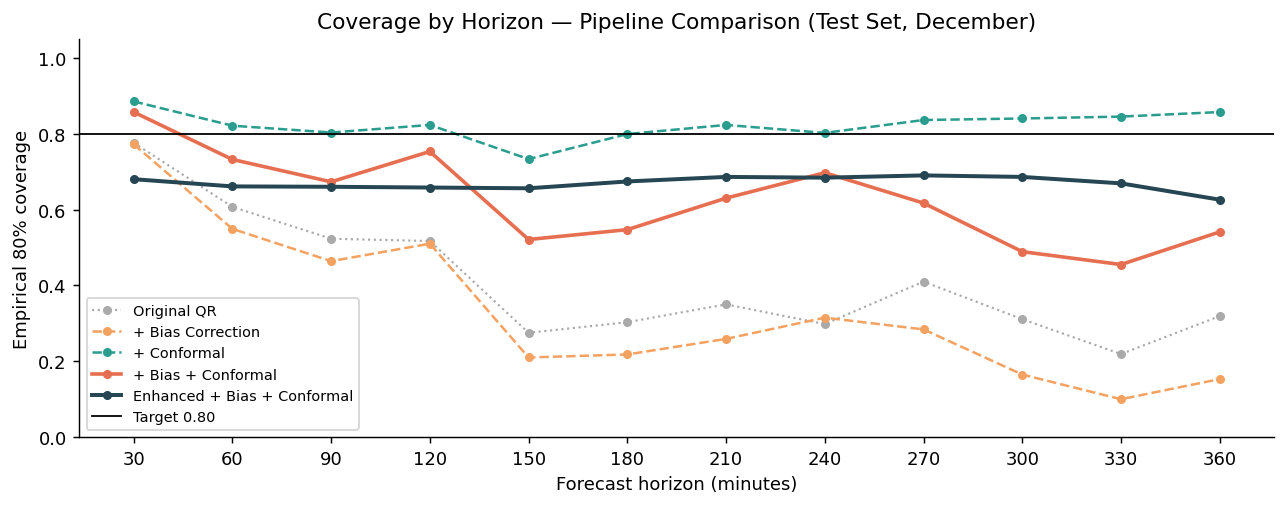

In [135]:
colours = ['#aaaaaa', '#f4a261', '#2a9d8f', '#e76f51', '#264653']
styles  = [':',       '--',      '--',       '-',       '-'      ]
lws     = [1.2,       1.4,       1.4,        2.0,       2.2      ]

fig, ax = plt.subplots(figsize=(10, 4))

for (name, _), col, sty, lw in zip(model_variants, colours, styles, lws):
    m = diag_all[name]
    ax.plot(m['horizon_min'], m['coverage80'],
            color=col, linestyle=sty, linewidth=lw,
            marker='o', markersize=4, label=name)

ax.axhline(1 - ALPHA, color='black', linewidth=1.0, linestyle='-',
           label=f'Target {1 - ALPHA:.2f}')
ax.set_xlabel('Forecast horizon (minutes)')
ax.set_ylabel('Empirical 80% coverage')
ax.set_title('Coverage by Horizon — Pipeline Comparison (Test Set, December)')
ax.set_xticks([h * 30 for h in HORIZONS])
ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

### 12.8.2  Interval Width vs. Coverage Trade-off

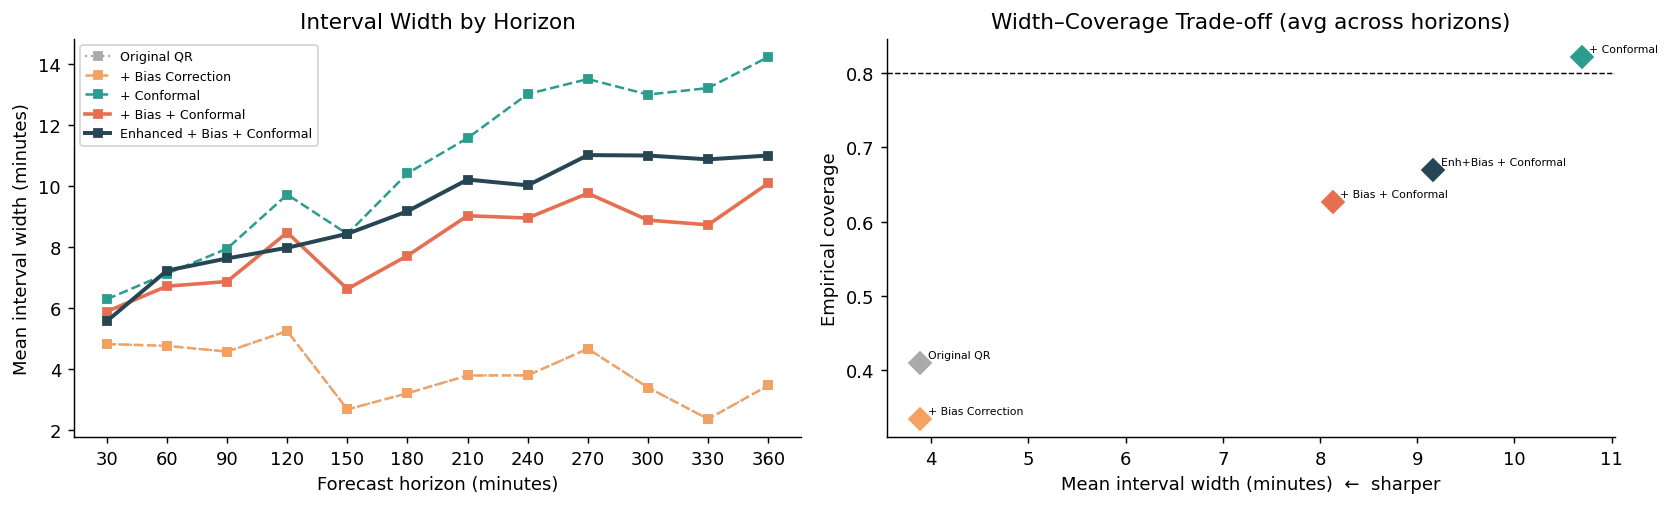

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for (name, _), col, sty, lw in zip(model_variants, colours, styles, lws):
    m = diag_all[name]
    # left: width by horizon
    axes[0].plot(m['horizon_min'], m['width80'],
                 color=col, linestyle=sty, linewidth=lw,
                 marker='s', markersize=4, label=name)
    # right: scatter width vs coverage
    axes[1].plot(m['width80'].mean(), m['coverage80'].mean(),
                 color=col, marker='D', markersize=9, linestyle='none', label=name)
    axes[1].annotate(name.replace('Enhanced + ', 'Enh+'),
                     (m['width80'].mean(), m['coverage80'].mean()),
                     fontsize=6, textcoords='offset points', xytext=(4, 3))

axes[0].set_xlabel('Forecast horizon (minutes)')
axes[0].set_ylabel('Mean interval width (minutes)')
axes[0].set_title('Interval Width by Horizon')
axes[0].set_xticks([h * 30 for h in HORIZONS])
axes[0].legend(fontsize=7)

axes[1].axhline(1 - ALPHA, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Mean interval width (minutes)  ←  sharper')
axes[1].set_ylabel('Empirical coverage')
axes[1].set_title('Width–Coverage Trade-off (avg across horizons)')

plt.tight_layout()
plt.show()

### 12.8.3  Median Forecast MAE by Horizon — All Variants

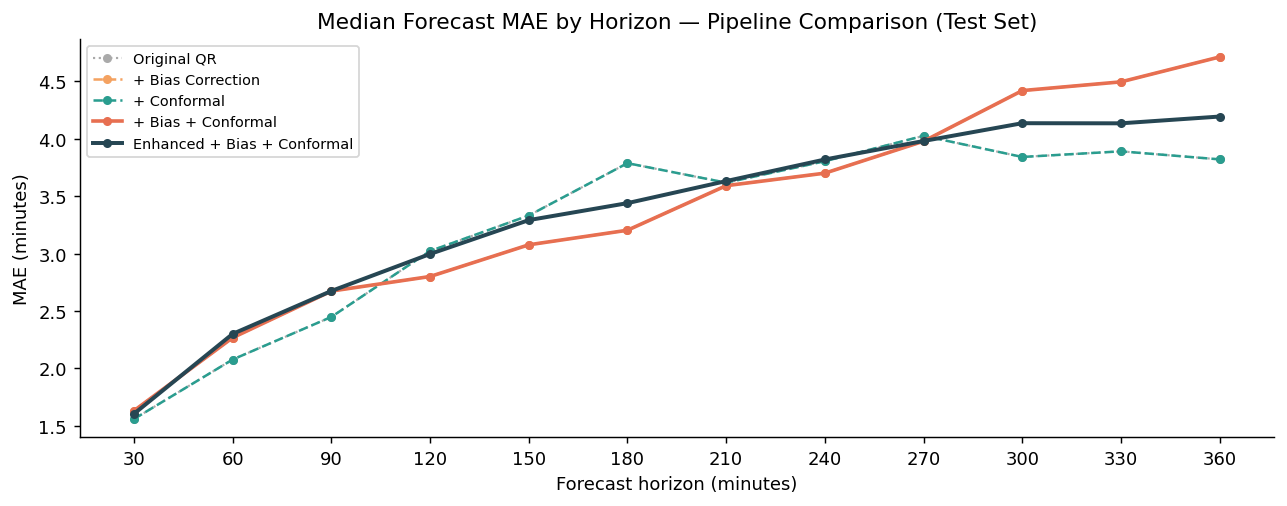

In [137]:
fig, ax = plt.subplots(figsize=(10, 4))

for (name, _), col, sty, lw in zip(model_variants, colours, styles, lws):
    m = diag_all[name]
    ax.plot(m['horizon_min'], m['MAE'],
            color=col, linestyle=sty, linewidth=lw,
            marker='o', markersize=4, label=name)

ax.set_xlabel('Forecast horizon (minutes)')
ax.set_ylabel('MAE (minutes)')
ax.set_title('Median Forecast MAE by Horizon — Pipeline Comparison (Test Set)')
ax.set_xticks([h * 30 for h in HORIZONS])
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 12.8.4  Calibration Heatmap — Original vs Best Model

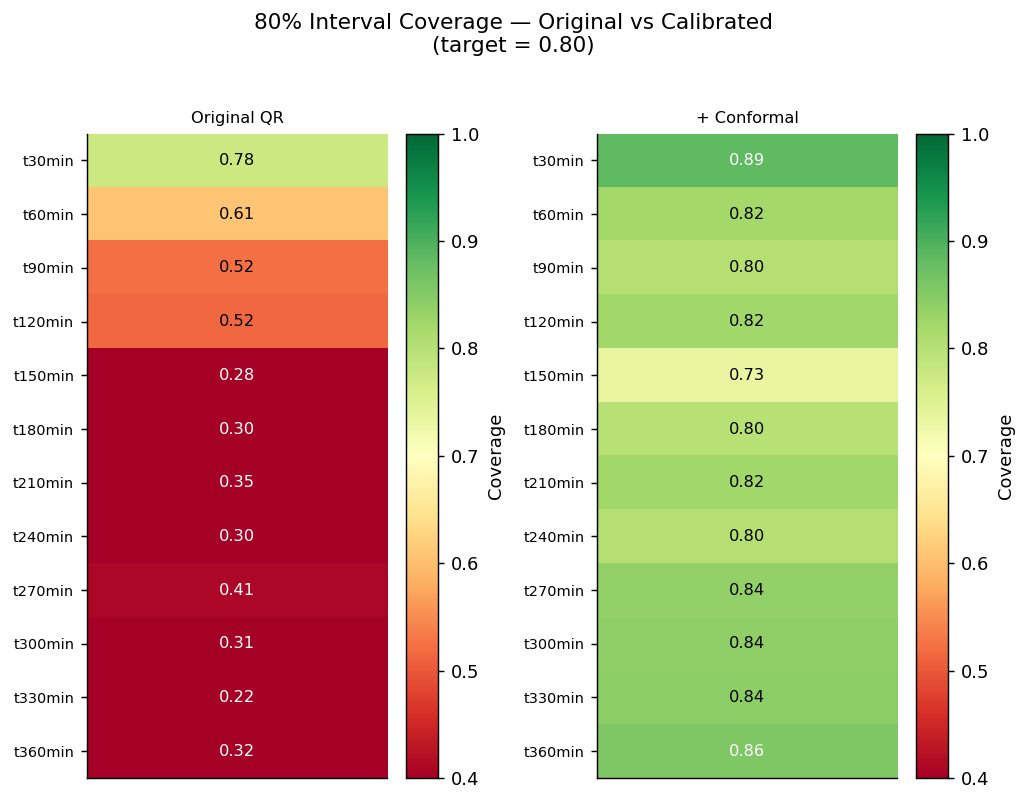

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))

for ax, (name, _) in zip(axes, [('Original QR', qr_pred_df),
                                  (best_name,     qrpreddf_enh_cal)]):
    m    = diag_all[name][['horizon_min', 'coverage80']].set_index('horizon_min')
    vals = m.values                           # shape (12, 1)
    im   = ax.imshow(vals, cmap='RdYlGn', vmin=0.40, vmax=1.00, aspect='auto')
    plt.colorbar(im, ax=ax, label='Coverage')
    ax.set_yticks(range(len(m.index)))
    ax.set_yticklabels([f't{v}min' for v in m.index], fontsize=8)
    ax.set_xticks([])
    for i, v in enumerate(vals.flatten()):
        txt_col = 'black' if 0.45 < v < 0.85 else 'white'
        ax.text(0, i, f'{v:.2f}', ha='center', va='center',
                fontsize=9, color=txt_col)
    ax.set_title(name, fontsize=9)

fig.suptitle(f'80% Interval Coverage — Original vs Calibrated\n(target = {1-ALPHA:.2f})',
             y=1.02)
plt.tight_layout()
plt.show()

## 12.9  Save All Calibrated Predictions

Four CSV files are saved, one per calibration variant, containing only the December
test-set rows so they can be used directly for downstream evaluation or deployment.

In [139]:
outputs = {
    'prediction_qr_bias_corrected.csv':       qr_pred_df_bc  [qr_pred_df_bc  ['split'] == 'test'],
    'prediction_qr_conformal.csv':            qr_pred_df_cf  [qr_pred_df_cf  ['split'] == 'test'],
    'prediction_qr_bias_conformal.csv':       qr_pred_df_comb[qr_pred_df_comb['split'] == 'test'],
    'prediction_qr_enhanced_calibrated.csv':  qrpreddf_enh_cal[qrpreddf_enh_cal['split'] == 'test'],
}

for fname, df in outputs.items():
    df.to_csv(fname, index=False)
    print(f"Saved  {fname}  ({len(df):,} rows, {df.shape[1]} columns)")

Saved  prediction_qr_bias_corrected.csv  (16,836 rows, 11 columns)
Saved  prediction_qr_conformal.csv  (16,836 rows, 11 columns)
Saved  prediction_qr_bias_conformal.csv  (16,836 rows, 11 columns)
Saved  prediction_qr_enhanced_calibrated.csv  (16,836 rows, 13 columns)
